<a href="https://colab.research.google.com/github/sanika-boop/CSL701-CS54Machine-Learning-Lab/blob/main/Copy_of_ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


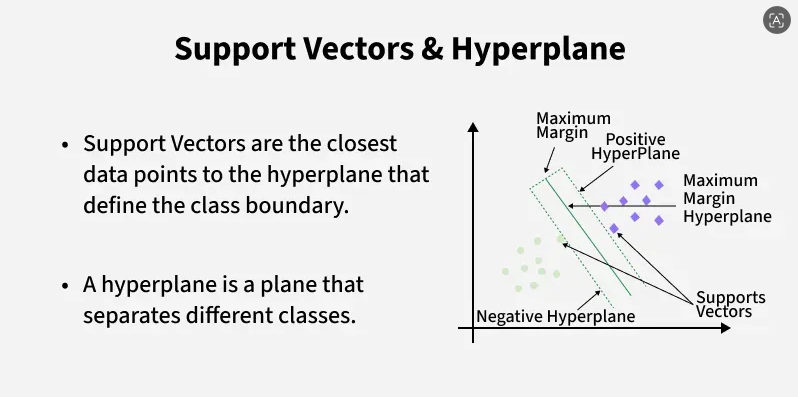
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [1]:
# Task 1: Import Libraries and Load Dataset

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Upload Iris.csv file
from google.colab import files
uploaded = files.upload()

# Load the Iris dataset
df = pd.read_csv("Iris.csv")

# Display the first 5 rows
print("First 5 rows of Iris Dataset:")
display(df.head())

# Display dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

Saving Iris.csv to Iris (1).csv
First 5 rows of Iris Dataset:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Dataset Shape: (150, 6)

Column Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


# Task 2: Explore the Dataset

In [2]:
# ============================================================
# TASK 2: EXPLORE THE DATASET
# ============================================================

# 1. Display the first 5 rows
print("First 5 Rows:")
display(df.head())


# 2. Display the last 5 rows
print("\nLast 5 Rows:")
display(df.tail())


# 3. Display number of rows and columns
print("\nDataset Shape:")
print(df.shape)


# 4. Display column names
print("\nColumn Names:")
print(df.columns.tolist())


# 5. Display dataset information
print("\nDataset Information:")
df.info()


# 6. Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


# 7. Check for duplicate rows
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())


# 8. Display statistical summary
print("\nStatistical Summary:")
display(df.describe())


# 9. Display unique species
print("\nUnique Species:")
print(df["Species"].unique())


# 10. Count the number of samples in each species
print("\nSpecies Distribution:")
print(df["Species"].value_counts())

First 5 Rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Last 5 Rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica



Dataset Shape:
(150, 6)

Column Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Number of Duplicate Rows:
0

Statistical Summary:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000



Unique Species:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Species Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [3]:
# ============================================================
# TASK 3: SELECT FEATURES AND TARGET
# ============================================================

# Remove the Id column
df = df.drop("Id", axis=1)

# Select features
X = df[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]]

# Select target
y = df["Species"]

# Display features
print("Selected Features:")
display(X.head())

# Display target
print("\nSelected Target:")
display(y.head())

# Display feature names
print("\nFeature Names:")
print(X.columns.tolist())

# Display target classes
print("\nTarget Classes:")
print(y.unique())

# Display shapes
print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

Selected Features:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Selected Target:


,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa



Feature Names:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Target Classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Features Shape: (150, 4)
Target Shape: (150,)


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [4]:
# ============================================================
# TASK 4: SPLIT AND SCALE THE DATA
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into training and testing sets
# 80% Training data and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)


# ============================================================
# Scale the features
# ============================================================

scaler = StandardScaler()

# Fit scaler only on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data using the same scaler
X_test_scaled = scaler.transform(X_test)


# Display scaled training data
print("\nScaled Training Data:")
print(X_train_scaled[:5])

# Display scaled testing data
print("\nScaled Testing Data:")
print(X_test_scaled[:5])

Training Features Shape: (120, 4)
Testing Features Shape: (30, 4)
Training Target Shape: (120,)
Testing Target Shape: (30,)

Scaled Training Data:
[[-1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [-1.12449223  0.12580502 -1.29021859 -1.45163753]
 [-0.40800161 -1.22612948  0.13020555  0.12599118]]

Scaled Testing Data:
[[-1.72156775 -0.0995174  -1.40385252 -1.32016847]
 [ 0.30848902 -0.0995174   0.64155823  0.78333648]
 [-1.12449223 -1.45145189 -0.26751321 -0.268416  ]
 [-1.00507713 -1.67677431 -0.26751321 -0.268416  ]
 [-1.72156775  0.35112743 -1.40385252 -1.32016847]]


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [5]:
# ============================================================
# TASK 5: IMPLEMENT LINEAR SVM
# ============================================================

from sklearn.svm import SVC

# Create SVM model with linear kernel
svm_model = SVC(kernel='linear', random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions on test data
y_pred = svm_model.predict(X_test_scaled)

# Display predictions
print("Predicted Values:")
print(y_pred)

# Display actual values
print("\nActual Values:")
print(y_test.values)

Predicted Values:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']

Actual Values:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 

# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


SVM Model Accuracy:
1.0000
Accuracy Percentage: 100.00%

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


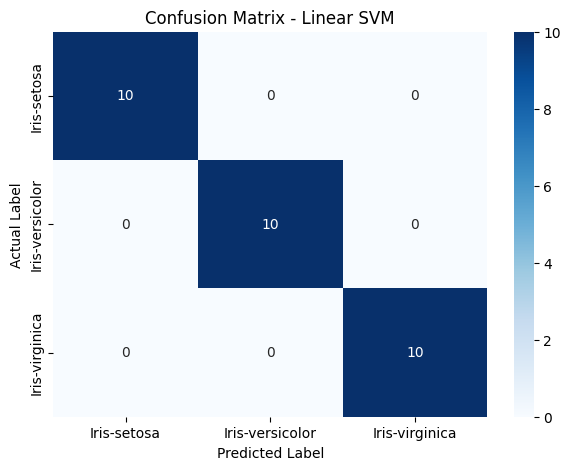


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [6]:
# ============================================================
# TASK 6: EVALUATE SVM
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. Calculate Accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("SVM Model Accuracy:")
print(f"{accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")


# ============================================================
# 2. Generate Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 3. Display Confusion Matrix as a Heatmap
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Linear SVM")
plt.show()


# ============================================================
# 4. Classification Report
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=svm_model.classes_
    )
)

# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

Selected Features:


,PetalLengthCm,PetalWidthCm
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2



Training Data Shape: (120, 2)
Testing Data Shape: (30, 2)

Predictions:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']


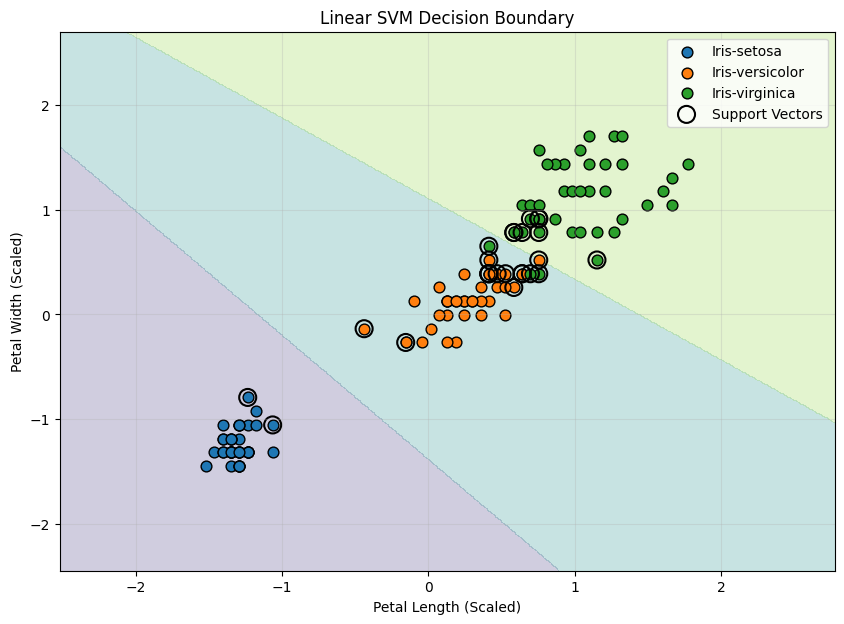

In [7]:
# ============================================================
# TASK 7: VISUALIZE SVM DECISION BOUNDARY
# ============================================================

# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Create the 2-D Dataset
# ============================================================

# Select only Petal Length and Petal Width
X_2D = df[["PetalLengthCm", "PetalWidthCm"]]
y_2D = df["Species"]

print("Selected Features:")
display(X_2D.head())


# ============================================================
# 2. Split the Data
# ============================================================

X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(
    X_2D,
    y_2D,
    test_size=0.20,
    random_state=42,
    stratify=y_2D
)

print("\nTraining Data Shape:", X_train_2D.shape)
print("Testing Data Shape:", X_test_2D.shape)


# ============================================================
# 3. Scale the Data
# ============================================================

scaler_2D = StandardScaler()

X_train_2D_scaled = scaler_2D.fit_transform(X_train_2D)
X_test_2D_scaled = scaler_2D.transform(X_test_2D)


# ============================================================
# 4. Train SVM with Linear Kernel
# ============================================================

svm_2D = SVC(
    kernel="linear",
    random_state=42
)

svm_2D.fit(X_train_2D_scaled, y_train_2D)


# ============================================================
# 5. Make Predictions
# ============================================================

y_pred_2D = svm_2D.predict(X_test_2D_scaled)

print("\nPredictions:")
print(y_pred_2D)


# ============================================================
# 6. Create Mesh Grid for Decision Boundary
# ============================================================

x_min = X_train_2D_scaled[:, 0].min() - 1
x_max = X_train_2D_scaled[:, 0].max() + 1

y_min = X_train_2D_scaled[:, 1].min() - 1
y_max = X_train_2D_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)


# ============================================================
# 7. Predict Each Point in the Mesh
# ============================================================

grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = svm_2D.predict(grid_points)

# Convert class labels to numeric values
class_to_number = {
    svm_2D.classes_[0]: 0,
    svm_2D.classes_[1]: 1,
    svm_2D.classes_[2]: 2
}

Z_numeric = np.array([class_to_number[label] for label in Z])
Z_numeric = Z_numeric.reshape(xx.shape)


# ============================================================
# 8. Plot SVM Decision Boundary
# ============================================================

plt.figure(figsize=(10, 7))

# Plot decision regions
plt.contourf(
    xx,
    yy,
    Z_numeric,
    alpha=0.25,
    levels=np.arange(-0.5, 3.5, 1)
)

# Plot training data points
for i, species in enumerate(svm_2D.classes_):
    mask = y_train_2D.values == species

    plt.scatter(
        X_train_2D_scaled[mask, 0],
        X_train_2D_scaled[mask, 1],
        label=species,
        edgecolors="black",
        s=60
    )

# Plot support vectors
plt.scatter(
    svm_2D.support_vectors_[:, 0],
    svm_2D.support_vectors_[:, 1],
    facecolors="none",
    edgecolors="black",
    s=150,
    linewidths=1.5,
    label="Support Vectors"
)

# Labels and title
plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Linear SVM Decision Boundary")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

Selected Features:


,PetalLengthCm,PetalWidthCm
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2



Training Data Shape: (120, 2)
Testing Data Shape: (30, 2)

Logistic Regression Predictions:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']


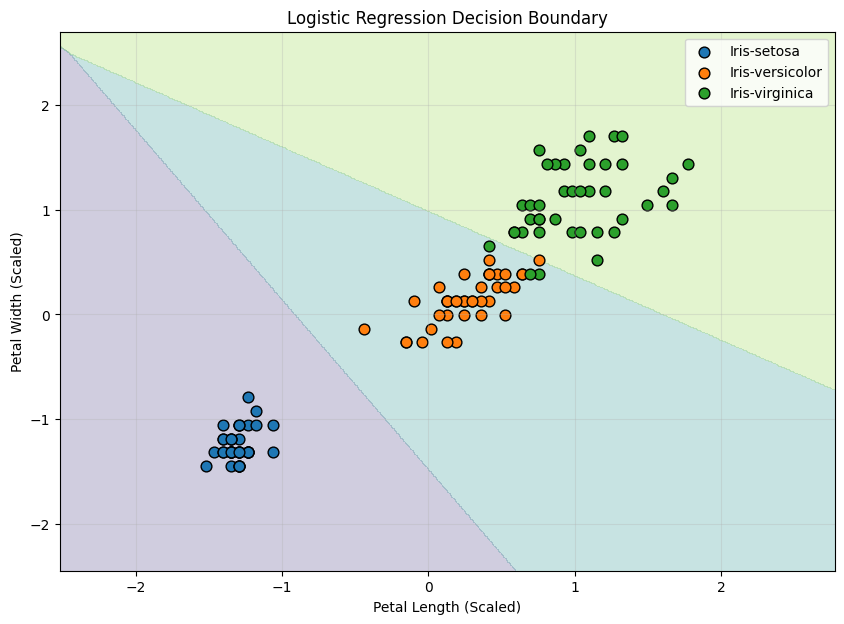

In [8]:
# ============================================================
# TASK 8: NORMAL LINEAR CLASSIFICATION BOUNDARY
# ============================================================

# Import required libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Create the 2-D Dataset
# ============================================================

# Select Petal Length and Petal Width
X_2D = df[["PetalLengthCm", "PetalWidthCm"]]
y_2D = df["Species"]

print("Selected Features:")
display(X_2D.head())


# ============================================================
# 2. Split the Data
# ============================================================

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_2D,
    y_2D,
    test_size=0.20,
    random_state=42,
    stratify=y_2D
)

print("\nTraining Data Shape:", X_train_lr.shape)
print("Testing Data Shape:", X_test_lr.shape)


# ============================================================
# 3. Scale the Data
# ============================================================

scaler_lr = StandardScaler()

X_train_lr_scaled = scaler_lr.fit_transform(X_train_lr)
X_test_lr_scaled = scaler_lr.transform(X_test_lr)


# ============================================================
# 4. Train Logistic Regression Model
# ============================================================

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_lr_scaled, y_train_lr)


# ============================================================
# 5. Make Predictions
# ============================================================

y_pred_lr = logistic_model.predict(X_test_lr_scaled)

print("\nLogistic Regression Predictions:")
print(y_pred_lr)


# ============================================================
# 6. Create Mesh Grid
# ============================================================

x_min = X_train_lr_scaled[:, 0].min() - 1
x_max = X_train_lr_scaled[:, 0].max() + 1

y_min = X_train_lr_scaled[:, 1].min() - 1
y_max = X_train_lr_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)


# ============================================================
# 7. Predict Classes for Mesh Grid
# ============================================================

grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = logistic_model.predict(grid_points)

# Convert class labels into numeric values
class_to_number = {
    logistic_model.classes_[0]: 0,
    logistic_model.classes_[1]: 1,
    logistic_model.classes_[2]: 2
}

Z_numeric = np.array([
    class_to_number[label] for label in Z
])

Z_numeric = Z_numeric.reshape(xx.shape)


# ============================================================
# 8. Plot Logistic Regression Decision Boundary
# ============================================================

plt.figure(figsize=(10, 7))

# Plot decision regions
plt.contourf(
    xx,
    yy,
    Z_numeric,
    alpha=0.25,
    levels=np.arange(-0.5, 3.5, 1)
)

# Plot training data points
for species in logistic_model.classes_:

    mask = y_train_lr.values == species

    plt.scatter(
        X_train_lr_scaled[mask, 0],
        X_train_lr_scaled[mask, 1],
        label=species,
        edgecolors="black",
        s=60
    )


# Labels and title
plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Logistic Regression Decision Boundary")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

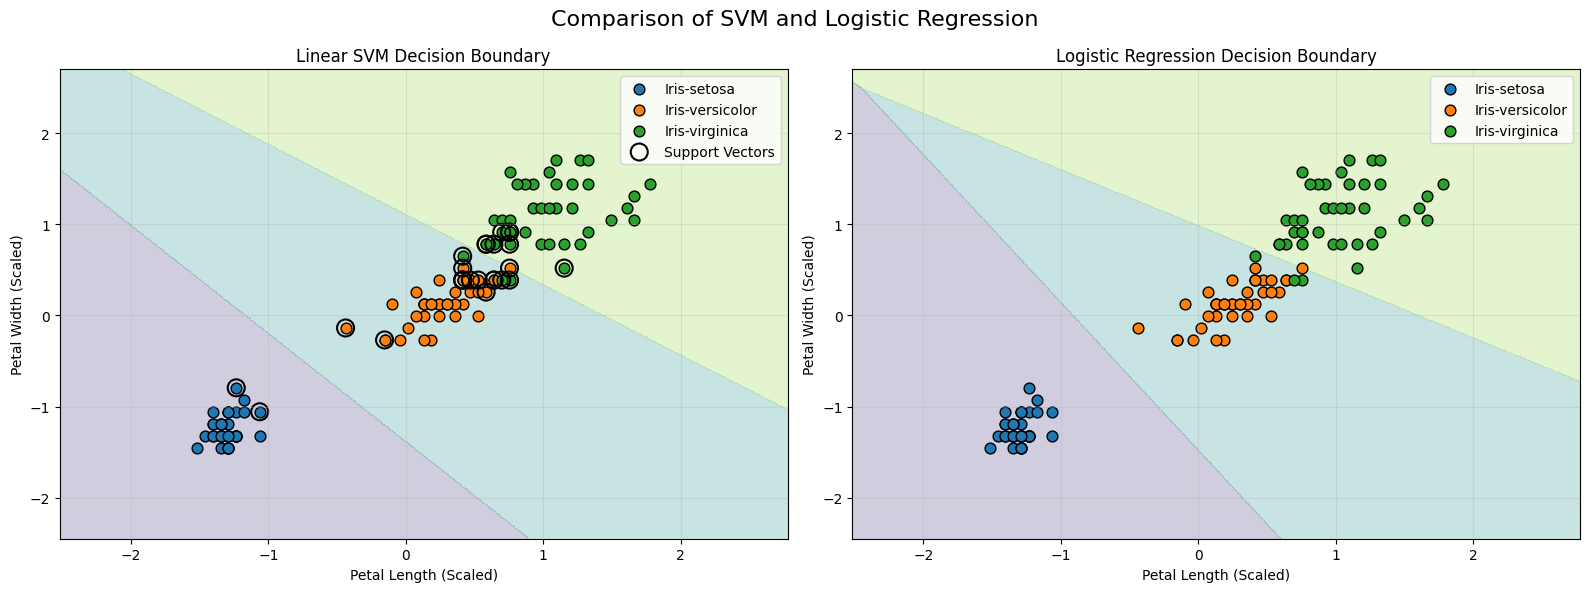

Model Performance Comparison
----------------------------------------
Linear SVM Accuracy:           0.9333
Logistic Regression Accuracy: 0.9333


In [9]:
# ============================================================
# TASK 9: COMPARE SVM AND LOGISTIC REGRESSION BOUNDARIES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# 1. Select Two Features
# ------------------------------------------------------------

X_2D = df[["PetalLengthCm", "PetalWidthCm"]]
y_2D = df["Species"]

# ------------------------------------------------------------
# 2. Split the Data
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_2D,
    y_2D,
    test_size=0.20,
    random_state=42,
    stratify=y_2D
)

# ------------------------------------------------------------
# 3. Scale the Data
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 4. Train Linear SVM
# ------------------------------------------------------------

svm_model = SVC(
    kernel="linear",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# 5. Train Logistic Regression
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# 6. Create Mesh Grid
# ------------------------------------------------------------

x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1

y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

# ------------------------------------------------------------
# 7. Predict Classes on Mesh Grid
# ------------------------------------------------------------

svm_grid_pred = svm_model.predict(grid_points)
lr_grid_pred = logistic_model.predict(grid_points)

# Convert class labels to numbers
class_to_number = {
    svm_model.classes_[0]: 0,
    svm_model.classes_[1]: 1,
    svm_model.classes_[2]: 2
}

svm_numeric = np.array(
    [class_to_number[label] for label in svm_grid_pred]
).reshape(xx.shape)

lr_numeric = np.array(
    [class_to_number[label] for label in lr_grid_pred]
).reshape(xx.shape)

# ------------------------------------------------------------
# 8. Plot Both Decision Boundaries
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================
# SVM DECISION BOUNDARY
# ============================================================

axes[0].contourf(
    xx,
    yy,
    svm_numeric,
    alpha=0.25,
    levels=np.arange(-0.5, 3.5, 1)
)

for species in svm_model.classes_:

    mask = y_train.values == species

    axes[0].scatter(
        X_train_scaled[mask, 0],
        X_train_scaled[mask, 1],
        s=60,
        edgecolors="black",
        label=species
    )

# Plot SVM support vectors
axes[0].scatter(
    svm_model.support_vectors_[:, 0],
    svm_model.support_vectors_[:, 1],
    facecolors="none",
    edgecolors="black",
    s=150,
    linewidths=1.5,
    label="Support Vectors"
)

axes[0].set_xlabel("Petal Length (Scaled)")
axes[0].set_ylabel("Petal Width (Scaled)")
axes[0].set_title("Linear SVM Decision Boundary")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ============================================================
# LOGISTIC REGRESSION DECISION BOUNDARY
# ============================================================

axes[1].contourf(
    xx,
    yy,
    lr_numeric,
    alpha=0.25,
    levels=np.arange(-0.5, 3.5, 1)
)

for species in logistic_model.classes_:

    mask = y_train.values == species

    axes[1].scatter(
        X_train_scaled[mask, 0],
        X_train_scaled[mask, 1],
        s=60,
        edgecolors="black",
        label=species
    )

axes[1].set_xlabel("Petal Length (Scaled)")
axes[1].set_ylabel("Petal Width (Scaled)")
axes[1].set_title("Logistic Regression Decision Boundary")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ------------------------------------------------------------
# 9. Display the Comparison
# ------------------------------------------------------------

plt.suptitle(
    "Comparison of SVM and Logistic Regression",
    fontsize=16
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Compare Accuracy
# ------------------------------------------------------------

svm_accuracy = svm_model.score(X_test_scaled, y_test)
lr_accuracy = logistic_model.score(X_test_scaled, y_test)

print("Model Performance Comparison")
print("-" * 40)
print(f"Linear SVM Accuracy:           {svm_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

ACCURACY COMPARISON
Linear SVM Accuracy:           0.9333
Linear SVM Accuracy (%):       93.33%

Logistic Regression Accuracy:  0.9333
Logistic Regression Accuracy (%): 93.33%

CONFUSION MATRIX - LINEAR SVM
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

CONFUSION MATRIX - LOGISTIC REGRESSION
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


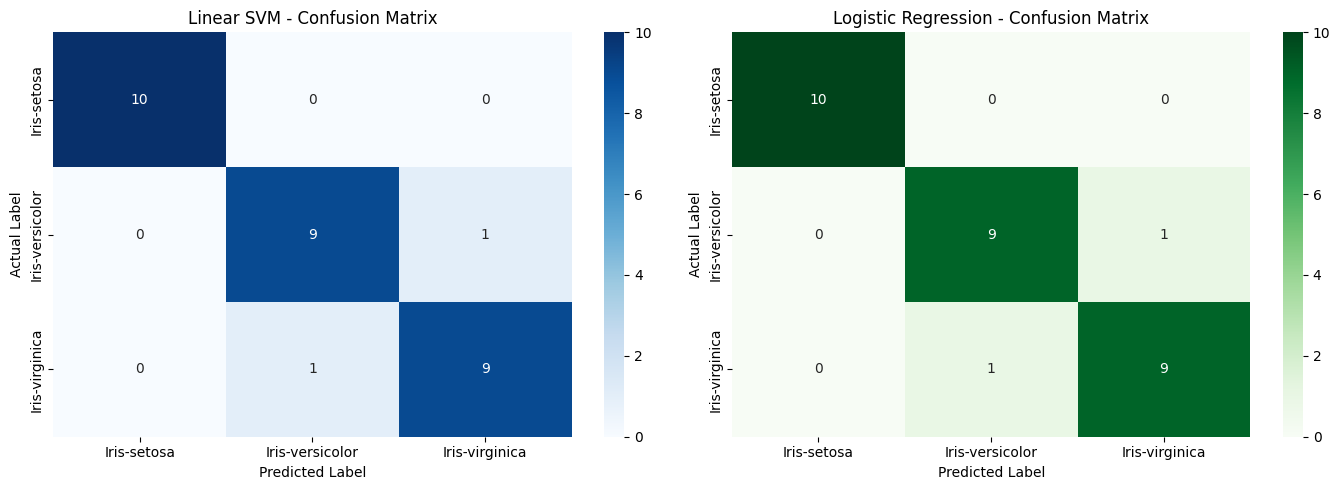


CLASSIFICATION REPORT - LINEAR SVM
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


CLASSIFICATION REPORT - LOGISTIC REGRESSION
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


FINAL PERFORMANCE COMPARISON


,Model,Accuracy,Accuracy (%)
0,Linear SVM,0.933333,93.333333
1,Logistic Regression,0.933333,93.333333


In [10]:
# ============================================================
# TASK 10: COMPARE PERFORMANCE
# Linear SVM vs Logistic Regression
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Make Predictions
# ------------------------------------------------------------

# Linear SVM predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Logistic Regression predictions
y_pred_lr = logistic_model.predict(X_test_scaled)

# ------------------------------------------------------------
# 2. Calculate Accuracy
# ------------------------------------------------------------

svm_accuracy = accuracy_score(y_test, y_pred_svm)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("=" * 60)
print("ACCURACY COMPARISON")
print("=" * 60)

print(f"Linear SVM Accuracy:           {svm_accuracy:.4f}")
print(f"Linear SVM Accuracy (%):       {svm_accuracy * 100:.2f}%")

print()

print(f"Logistic Regression Accuracy:  {lr_accuracy:.4f}")
print(f"Logistic Regression Accuracy (%): {lr_accuracy * 100:.2f}%")

# ------------------------------------------------------------
# 3. Confusion Matrices
# ------------------------------------------------------------

cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("\n" + "=" * 60)
print("CONFUSION MATRIX - LINEAR SVM")
print("=" * 60)
print(cm_svm)

print("\n" + "=" * 60)
print("CONFUSION MATRIX - LOGISTIC REGRESSION")
print("=" * 60)
print(cm_lr)

# ------------------------------------------------------------
# 4. Plot Confusion Matrices
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear SVM Confusion Matrix
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_,
    ax=axes[0]
)

axes[0].set_title("Linear SVM - Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")

# Logistic Regression Confusion Matrix
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=logistic_model.classes_,
    yticklabels=logistic_model.classes_,
    ax=axes[1]
)

axes[1].set_title("Logistic Regression - Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Classification Report - Linear SVM
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT - LINEAR SVM")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=svm_model.classes_
    )
)

# ------------------------------------------------------------
# 6. Classification Report - Logistic Regression
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT - LOGISTIC REGRESSION")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=logistic_model.classes_
    )
)

# ------------------------------------------------------------
# 7. Final Performance Comparison Table
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL PERFORMANCE COMPARISON")
print("=" * 60)

comparison = {
    "Model": [
        "Linear SVM",
        "Logistic Regression"
    ],
    "Accuracy": [
        svm_accuracy,
        lr_accuracy
    ],
    "Accuracy (%)": [
        svm_accuracy * 100,
        lr_accuracy * 100
    ]
}

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.